# 02 — Exploratory Data Analysis

Creates descriptive statistics and the main healthcare-risk visualizations requested in the project documents.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / 'data').exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.analytics import add_dashboard_columns

df = pd.read_csv(ROOT / 'data' / 'cleaned_data.csv')
df = add_dashboard_columns(df)
print(df.describe(include='all').T)

                    count unique           top  freq        mean        std  \
Patient ID           1500   1500        P00001     1         NaN        NaN   
Age                1500.0    NaN           NaN   NaN   49.298667  18.206037   
Gender               1500      2          Male   768         NaN        NaN   
BMI                1500.0    NaN           NaN   NaN     26.1074   4.238375   
Blood Pressure     1500.0    NaN           NaN   NaN  123.119333  16.395252   
Glucose Level      1500.0    NaN           NaN   NaN  100.522667  21.795309   
Cholesterol        1500.0    NaN           NaN   NaN     193.292  30.980853   
Smoking Status       1500      3         Never   858         NaN        NaN   
Physical Activity    1500      3      Moderate   743         NaN        NaN   
Medical History      1500      3  Hypertension  1107         NaN        NaN   
Health Risk          1500      3        Medium   577         NaN        NaN   
Age Group            1500      4           60+   509

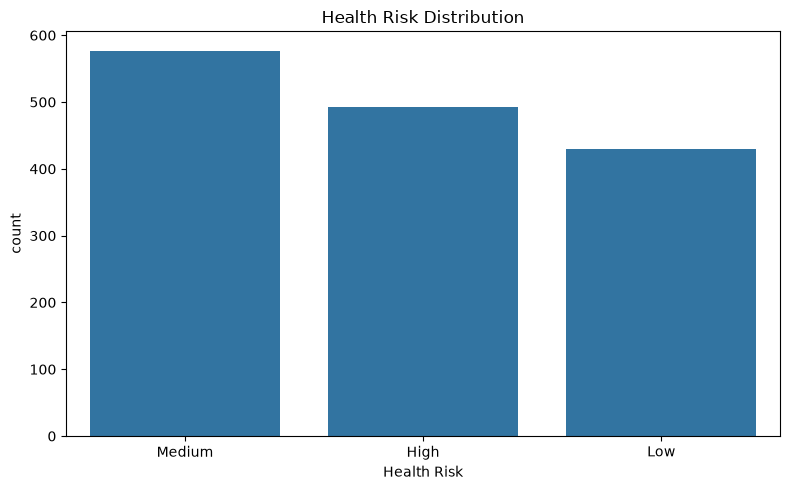

In [2]:
OUT = ROOT / 'outputs' / 'graphs'
OUT.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Health Risk', order=df['Health Risk'].value_counts().index)
plt.title('Health Risk Distribution')
plt.tight_layout()
plt.savefig(OUT/'risk_distribution.png', dpi=160)
plt.show()

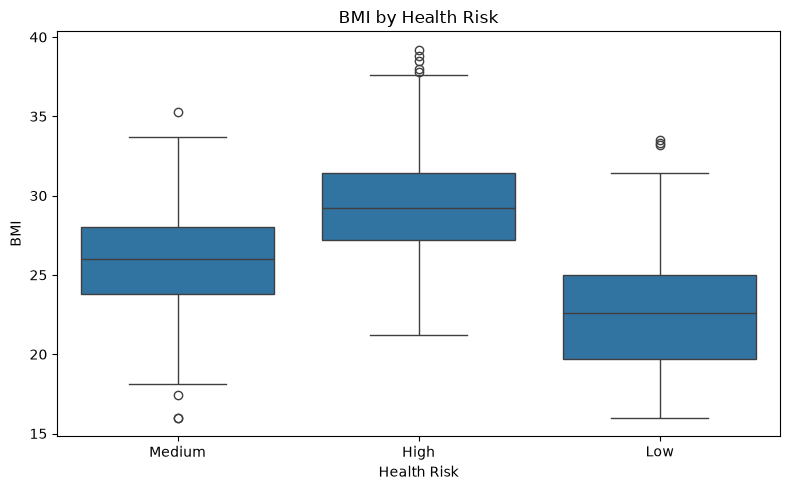

In [3]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Health Risk', y='BMI')
plt.title('BMI by Health Risk')
plt.tight_layout()
plt.savefig(OUT/'bmi_vs_risk.png', dpi=160)
plt.show()

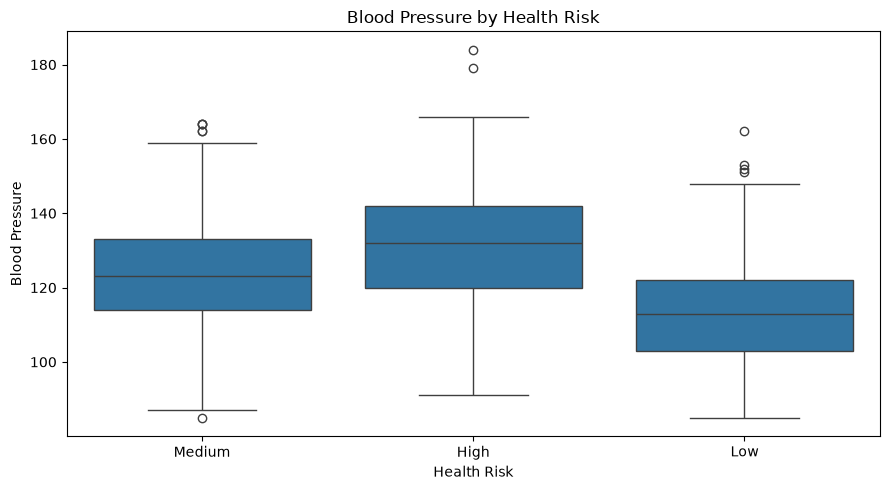

In [4]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x='Health Risk', y='Blood Pressure')
plt.title('Blood Pressure by Health Risk')
plt.tight_layout()
plt.savefig(OUT/'blood_pressure_vs_risk.png', dpi=160)
plt.show()

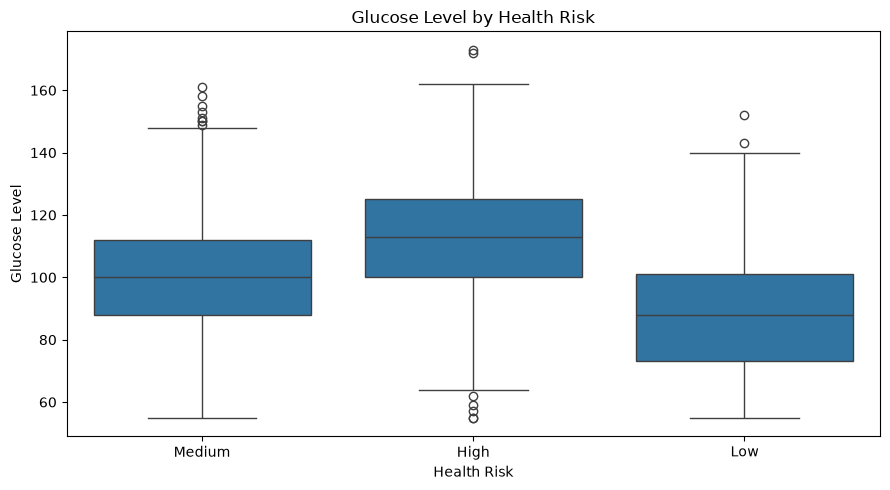

In [5]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x='Health Risk', y='Glucose Level')
plt.title('Glucose Level by Health Risk')
plt.tight_layout()
plt.savefig(OUT/'glucose_vs_risk.png', dpi=160)
plt.show()

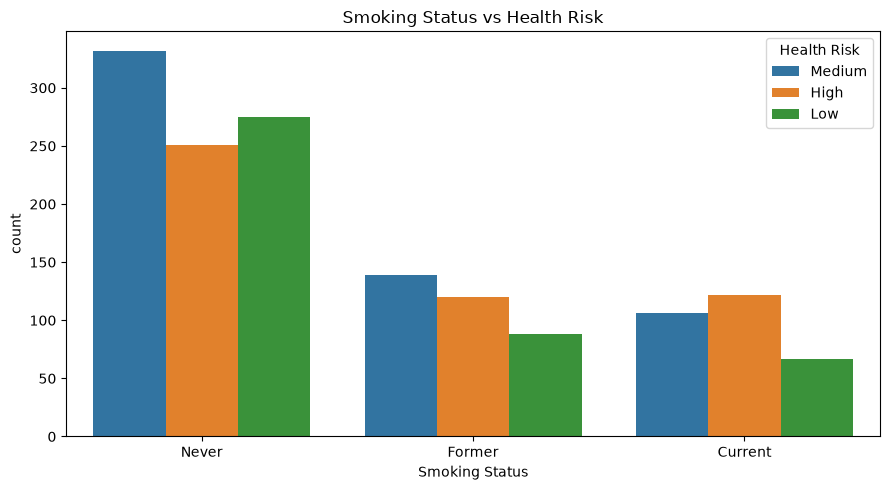

In [6]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x='Smoking Status', hue='Health Risk')
plt.title('Smoking Status vs Health Risk')
plt.tight_layout()
plt.savefig(OUT/'smoking_vs_risk.png', dpi=160)
plt.show()

**Interpretation note:** the charts describe patterns in the dataset. They do not establish medical causation.